# Calibration check — Victimization model

Este notebook hace **solo evaluación de calibración** para el modelo de victimización.

No recalibra el modelo, no modifica el threshold y no cambia las métricas principales del paper. Solo comprueba si los scores/probabilidades del modelo están alineados con la prevalencia observada en el test set.

Archivos esperados en la misma carpeta del notebook:

- `predictions_with_probabilities.csv`
- `y_test.csv` *(opcional, se usa para comprobar coherencia)*
- `y_train.csv` *(opcional, se usa solo para describir prevalencias train/test)*

Para este primer paso **no hace falta cargar `modelo_pca.pkl`**, porque el CSV ya contiene `probability_class1`, que es el score/probabilidad de la clase positiva.

## 1. Cargar librerías

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

## 2. Cargar archivos

Usamos rutas relativas para que el notebook funcione si los CSV están en la misma carpeta.

In [2]:
DATA_DIR = Path(".")

pred_path = DATA_DIR / "predictions_with_probabilities.csv"
y_test_path = DATA_DIR / "y_test.csv"
y_train_path = DATA_DIR / "y_train.csv"

pred = pd.read_csv(pred_path)
print("predictions_with_probabilities.csv:", pred.shape)
display(pred.head())
print(pred.columns.tolist())

predictions_with_probabilities.csv: (942, 5)


,ori_idx,real_value,predicted_value,probability_predicted_class,probability_class1
0,3001,1.0,0.0,0.748988,0.251012
1,1694,0.0,0.0,0.748988,0.251012
2,677,0.0,0.0,0.748988,0.251012
3,840,0.0,1.0,0.545689,0.545689
4,1903,0.0,1.0,0.545689,0.545689


['ori_idx', 'real_value', 'predicted_value', 'probability_predicted_class', 'probability_class1']


## 3. Identificar `y_true` y `y_score`

En este archivo:

- `real_value` = valor real observado, es decir, `y_true`/`y_test`.
- `probability_class1` = probabilidad/score de la clase positiva, es decir, `y_score`.
- `predicted_value` = predicción binaria final 0/1. **No se usa para calibración**.
- `probability_predicted_class` = probabilidad de la clase predicha. **No se usa para calibración**, porque cambia de significado según el modelo prediga 0 o 1.

Para calibración necesitamos siempre la probabilidad de la clase positiva: `probability_class1`.

In [3]:
y_true = pred["real_value"].astype(int).to_numpy()
y_score = pred["probability_class1"].astype(float).to_numpy()

print("n y_true:", len(y_true))
print("n y_score:", len(y_score))
print("Valores únicos en y_true:", np.unique(y_true, return_counts=True))
print("Mínimo y_score:", y_score.min())
print("Máximo y_score:", y_score.max())
print("Media y_score:", y_score.mean())
print("Prevalencia observada en test:", y_true.mean())
print("Número de valores únicos en y_score:", len(np.unique(y_score)))
print("Valores únicos en y_score:", np.unique(y_score))

n y_true: 942
n y_score: 942
Valores únicos en y_true: (array([0, 1]), array([477, 465]))
Mínimo y_score: 0.2510121457489878
Máximo y_score: 0.5456885456885456
Media y_score: 0.4950117125779208
Prevalencia observada en test: 0.49363057324840764
Número de valores únicos en y_score: 2
Valores únicos en y_score: [0.25101215 0.54568855]


## 4. Comprobación opcional con `y_test.csv`

Esta celda comprueba que `real_value` del archivo de predicciones coincide con `VÍCTIMA` en `y_test.csv`, usando el índice original.

In [4]:
if y_test_path.exists():
    y_test_df = pd.read_csv(y_test_path)
    print("y_test.csv:", y_test_df.shape)
    display(y_test_df.head())
    
    # En estos archivos, `ori_idx` en predicciones corresponde a `Unnamed: 0` en y_test.csv.
    check = pred[["ori_idx", "real_value"]].merge(
        y_test_df.rename(columns={"Unnamed: 0": "ori_idx", "VÍCTIMA": "victim_y_test"}),
        on="ori_idx",
        how="left"
    )
    
    n_missing = check["victim_y_test"].isna().sum()
    n_disagree = (check["real_value"] != check["victim_y_test"]).sum()
    
    print("Filas sin match:", n_missing)
    print("Desacuerdos entre real_value y y_test.csv:", n_disagree)
else:
    print("No se encontró y_test.csv. Se continúa con real_value del archivo de predicciones.")

y_test.csv: (942, 2)


,Unnamed: 0,VÍCTIMA
0,3001,1.0
1,1694,0.0
2,677,0.0
3,840,0.0
4,1903,0.0


Filas sin match: 0
Desacuerdos entre real_value y y_test.csv: 0


## 5. Función de comprobación

Esta función avisa si por error hemos usado una predicción binaria 0/1 en lugar de un score continuo/probabilidad.

En este modelo puede aparecer un aviso porque el árbol solo genera dos probabilidades distintas. Eso no impide calcular Brier ni una curva básica, pero sí limita la tabla por deciles.

In [5]:
def check_calibration_inputs(y_true, y_score, name="model"):
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()

    print(f"=== {name} ===")
    print("n y_true:", len(y_true))
    print("n y_score:", len(y_score))
    print("Valores únicos en y_true:", np.unique(y_true))
    print("Mínimo y_score:", np.min(y_score))
    print("Máximo y_score:", np.max(y_score))
    print("Media y_score:", np.mean(y_score))
    print("Prevalencia observada:", np.mean(y_true))
    print("Número de valores únicos en y_score:", len(np.unique(y_score)))

    if len(y_true) != len(y_score):
        raise ValueError("ERROR: y_true e y_score no tienen la misma longitud.")

    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError("ERROR: y_true debería contener solo 0 y 1.")

    if np.min(y_score) < 0 or np.max(y_score) > 1:
        print("AVISO: y_score tiene valores fuera de 0-1. Puede que no sean probabilidades.")

    if len(np.unique(y_score)) <= 2:
        print("AVISO: y_score tiene dos o menos valores únicos. Esto puede ocurrir en árboles simples o podados.")
        print("Para calibración fina por deciles no es ideal, pero sirve para una evaluación básica del output del modelo.")

check_calibration_inputs(y_true, y_score, name="Victimization")

=== Victimization ===
n y_true: 942
n y_score: 942
Valores únicos en y_true: [0 1]
Mínimo y_score: 0.2510121457489878
Máximo y_score: 0.5456885456885456
Media y_score: 0.4950117125779208
Prevalencia observada: 0.49363057324840764
Número de valores únicos en y_score: 2
AVISO: y_score tiene dos o menos valores únicos. Esto puede ocurrir en árboles simples o podados.
Para calibración fina por deciles no es ideal, pero sirve para una evaluación básica del output del modelo.


## 6. Brier score y resumen básico

El Brier score resume el error cuadrático medio entre la probabilidad/score predicho y el resultado observado. Menor es mejor.

También calculamos un Brier score de referencia usando la prevalencia del test como probabilidad constante para todos los casos. Esto ayuda a interpretar si el score del modelo mejora respecto a asignar a todo el mundo la misma probabilidad base.

In [6]:
brier = brier_score_loss(y_true, y_score)
prevalence_test = y_true.mean()
brier_baseline = brier_score_loss(y_true, np.repeat(prevalence_test, len(y_true)))

summary = pd.DataFrame({
    "model": ["Victimization"],
    "n_test": [len(y_true)],
    "observed_prevalence_test": [prevalence_test],
    "mean_predicted_score": [y_score.mean()],
    "brier_score": [brier],
    "brier_baseline_prevalence_only": [brier_baseline],
    "n_unique_scores": [len(np.unique(y_score))]
})

display(summary)
summary.to_csv("victimization_calibration_summary.csv", index=False)
print("Archivo guardado: victimization_calibration_summary.csv")

,model,n_test,observed_prevalence_test,mean_predicted_score,brier_score,brier_baseline_prevalence_only,n_unique_scores
0,Victimization,942,0.493631,0.495012,0.239823,0.249959,2


Archivo guardado: victimization_calibration_summary.csv


## 7. Tabla por valores únicos de score

Como este árbol solo produce dos scores distintos, esta tabla es más informativa que una tabla por deciles. Muestra, para cada score, cuántos casos hay y qué prevalencia real se observa.

In [7]:
df_cal = pd.DataFrame({
    "y_true": y_true,
    "y_score": y_score,
    "predicted_value": pred["predicted_value"].astype(int).to_numpy()
})

unique_score_table = (
    df_cal.groupby("y_score", observed=True)
    .agg(
        n=("y_true", "size"),
        positives_observed=("y_true", "sum"),
        observed_prevalence=("y_true", "mean"),
        predicted_positive_rate=("predicted_value", "mean")
    )
    .reset_index()
    .rename(columns={"y_score": "mean_predicted_score"})
)

unique_score_table["calibration_error_observed_minus_predicted"] = (
    unique_score_table["observed_prevalence"] - unique_score_table["mean_predicted_score"]
)
unique_score_table["abs_calibration_error"] = unique_score_table["calibration_error_observed_minus_predicted"].abs()

# Ordenar de menor a mayor score
unique_score_table = unique_score_table.sort_values("mean_predicted_score").reset_index(drop=True)

display(unique_score_table)
unique_score_table.to_csv("victimization_calibration_table_unique_scores.csv", index=False)
print("Archivo guardado: victimization_calibration_table_unique_scores.csv")

,mean_predicted_score,n,positives_observed,observed_prevalence,predicted_positive_rate,calibration_error_observed_minus_predicted,abs_calibration_error
0,0.251012,162,44,0.271605,0.0,0.020593,0.020593
1,0.545689,780,421,0.539744,1.0,-0.005945,0.005945


Archivo guardado: victimization_calibration_table_unique_scores.csv


## 8. Tabla por bins cuantiles/deciles

Intentamos hacer 10 bins por cuantiles. Si hay pocos valores únicos de score, `pd.qcut` colapsa bins. En este caso, al haber solo dos scores, puede salir una tabla con muy pocos grupos.

In [8]:
def quantile_bin_table(y_true, y_score, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_score": y_score})
    unique_scores = len(np.unique(y_score))
    q = min(n_bins, unique_scores)
    
    if q < 2:
        raise ValueError("No hay suficientes valores únicos para crear bins.")
    
    df["score_bin"] = pd.qcut(df["y_score"], q=q, duplicates="drop")
    
    table = (
        df.groupby("score_bin", observed=True)
        .agg(
            n=("y_true", "size"),
            min_score=("y_score", "min"),
            max_score=("y_score", "max"),
            mean_predicted_score=("y_score", "mean"),
            observed_prevalence=("y_true", "mean")
        )
        .reset_index()
    )
    table["calibration_error_observed_minus_predicted"] = (
        table["observed_prevalence"] - table["mean_predicted_score"]
    )
    table["abs_calibration_error"] = table["calibration_error_observed_minus_predicted"].abs()
    return table

try:
    bin_table = quantile_bin_table(y_true, y_score, n_bins=10)
    display(bin_table)
    bin_table.to_csv("victimization_calibration_table_quantile_bins.csv", index=False)
    print("Archivo guardado: victimization_calibration_table_quantile_bins.csv")
except Exception as e:
    print("No se pudo crear tabla por cuantiles:", e)
    bin_table = None

,score_bin,n,min_score,max_score,mean_predicted_score,observed_prevalence,calibration_error_observed_minus_predicted,abs_calibration_error
0,"(0.25, 0.546]",942,0.251012,0.545689,0.495012,0.493631,-0.001381,0.001381


Archivo guardado: victimization_calibration_table_quantile_bins.csv


## 9. Curva de calibración

La diagonal representa calibración perfecta. Puntos por debajo de la diagonal indican sobreestimación; puntos por encima indican infraestimación.

Como este modelo tiene solo dos scores distintos, la curva tendrá pocos puntos.

,mean_predicted_score,observed_prevalence
0,0.495012,0.493631


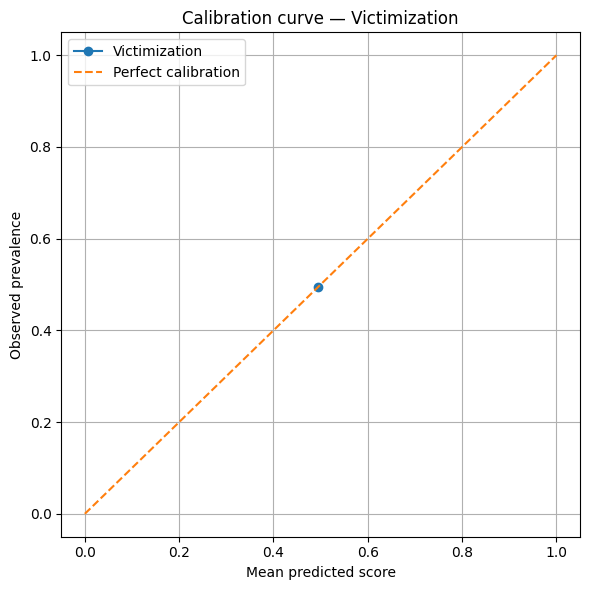

Archivo guardado: victimization_calibration_curve.png
Archivo guardado: victimization_calibration_curve_points.csv


In [9]:
n_unique = len(np.unique(y_score))
n_bins_curve = min(10, n_unique)

prob_true, prob_pred = calibration_curve(
    y_true,
    y_score,
    n_bins=n_bins_curve,
    strategy="quantile"
)

curve_df = pd.DataFrame({
    "mean_predicted_score": prob_pred,
    "observed_prevalence": prob_true
})
display(curve_df)
curve_df.to_csv("victimization_calibration_curve_points.csv", index=False)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Victimization")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted score")
plt.ylabel("Observed prevalence")
plt.title("Calibration curve — Victimization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("victimization_calibration_curve.png", dpi=300)
plt.show()

print("Archivo guardado: victimization_calibration_curve.png")
print("Archivo guardado: victimization_calibration_curve_points.csv")

## 10. Interpretación automática para este modelo

Esta celda imprime una lectura breve basada en los resultados.

In [10]:
print("=== Interpretación breve — Victimization ===")
print(f"N test = {len(y_true)}")
print(f"Prevalencia observada en test = {prevalence_test:.3f}")
print(f"Score medio predicho = {y_score.mean():.3f}")
print(f"Brier score = {brier:.4f}")
print(f"Brier baseline prevalence-only = {brier_baseline:.4f}")
print(f"Número de scores únicos = {n_unique}")

print("\nTabla por score único:")
for _, row in unique_score_table.iterrows():
    print(
        f"- Score {row['mean_predicted_score']:.3f}: "
        f"n={int(row['n'])}, "
        f"prevalencia observada={row['observed_prevalence']:.3f}, "
        f"error obs-pred={row['calibration_error_observed_minus_predicted']:.3f}"
    )

if n_unique <= 2:
    print("\nNota: el modelo solo produce dos niveles de score, por lo que no permite una evaluación fina por deciles.")
    print("Esto apoya describir los outputs como screening/prioritization scores, no como probabilidades clínicas finamente calibradas.")

=== Interpretación breve — Victimization ===
N test = 942
Prevalencia observada en test = 0.494
Score medio predicho = 0.495
Brier score = 0.2398
Brier baseline prevalence-only = 0.2500
Número de scores únicos = 2

Tabla por score único:
- Score 0.251: n=162, prevalencia observada=0.272, error obs-pred=0.021
- Score 0.546: n=780, prevalencia observada=0.540, error obs-pred=-0.006

Nota: el modelo solo produce dos niveles de score, por lo que no permite una evaluación fina por deciles.
Esto apoya describir los outputs como screening/prioritization scores, no como probabilidades clínicas finamente calibradas.


## 11. Texto prudente para Method/Results

Texto posible para Method:

> Calibration was examined in the held-out test partition using Brier scores and calibration curves. Because the final victimization decision tree produced a limited number of distinct probability scores, calibration was additionally summarized by unique score levels rather than relying exclusively on decile-based bins.

Texto posible para Results, adaptando los valores que aparecen arriba:

> For the victimization model, the mean predicted score was close to the observed test prevalence, and the Brier score was slightly lower than the prevalence-only reference value. However, the final tree produced only two distinct score levels, limiting fine-grained probability interpretation. Therefore, model outputs were interpreted as internally evaluated screening/prioritization scores rather than externally validated individual risk probabilities.